# Missing Value Imputation Experiments

## Objective

Compare 4 missing value imputation strategies using 5-fold stratified cross-validation:

1. **Global Mean/Mode** - Impute with overall mean for numerical, mode for categorical
2. **Global Median/Mode** - Impute with overall median for numerical, mode for categorical
3. **Constant Filling** - Impute with -999 for numerical, 'MISSING' for categorical
4. **Class-Specific Mean/Mode** - Impute with class-specific mean/mode

## Evaluation

- **Model**: DecisionTreeClassifier (max_depth=10)
- **CV**: StratifiedKFold (n_splits=5, random_state=42)
- **Metrics**: F1 Score (primary), Accuracy (secondary)


---

## 1. Setup and Data Loading


In [1]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

# Set random seed for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("Imports successful!")

Imports successful!


In [2]:
# Load data
train_df = pd.read_csv("../data/train.csv")
test_df = pd.read_csv("../data/test_data.csv")

# Separate features and target
X = train_df.drop("Target (Col44)", axis=1)
y = train_df["Target (Col44)"]

# Identify feature types
num_cols = [col for col in X.columns if col.startswith("Num_")]
cat_cols = [col for col in X.columns if col.startswith("Nom_")]

print(f"Dataset Info:")
print(f"  Training samples: {len(X)}")
print(f"  Numerical features: {len(num_cols)}")
print(f"  Categorical features: {len(cat_cols)}")
print(f"\nMissing Value Statistics:")
print(f"  Training set missing rate: {X.isnull().sum().sum() / X.size * 100:.2f}%")
print(
    f"  Rows with at least one missing: {X.isnull().any(axis=1).sum()} ({X.isnull().any(axis=1).sum()/len(X)*100:.2f}%)"
)
print(
    f"  Test set missing rate: {test_df.isnull().sum().sum() / test_df.size * 100:.2f}%"
)
print(f"\nTarget Distribution:")
print(y.value_counts())
print(f"  Class imbalance ratio: {y.value_counts()[0] / y.value_counts()[1]:.2f}:1")

Dataset Info:
  Training samples: 10853
  Numerical features: 25
  Categorical features: 18

Missing Value Statistics:
  Training set missing rate: 10.00%
  Rows with at least one missing: 10734 (98.90%)
  Test set missing rate: 0.00%

Target Distribution:
Target (Col44)
0    8170
1    2683
Name: count, dtype: int64
  Class imbalance ratio: 3.05:1


---

## 2. Imputation Functions

Define 4 different imputation strategies.


In [3]:
def impute_global_mean(X_train, X_val, num_cols, cat_cols):
    """
    Method 1: Global Mean/Mode Imputation
    - Numerical: mean of all training samples
    - Categorical: most_frequent of all training samples
    """
    X_train_copy = X_train.copy()
    X_val_copy = X_val.copy()

    # Numerical features: mean
    num_imputer = SimpleImputer(strategy="mean")
    X_train_copy[num_cols] = num_imputer.fit_transform(X_train[num_cols])
    X_val_copy[num_cols] = num_imputer.transform(X_val[num_cols])

    # Categorical features: most_frequent
    cat_imputer = SimpleImputer(strategy="most_frequent")
    X_train_copy[cat_cols] = cat_imputer.fit_transform(X_train[cat_cols])
    X_val_copy[cat_cols] = cat_imputer.transform(X_val[cat_cols])

    return X_train_copy, X_val_copy


def impute_global_median(X_train, X_val, num_cols, cat_cols):
    """
    Method 2: Global Median/Mode Imputation
    - Numerical: median of all training samples (robust to outliers)
    - Categorical: most_frequent of all training samples
    """
    X_train_copy = X_train.copy()
    X_val_copy = X_val.copy()

    # Numerical features: median
    num_imputer = SimpleImputer(strategy="median")
    X_train_copy[num_cols] = num_imputer.fit_transform(X_train[num_cols])
    X_val_copy[num_cols] = num_imputer.transform(X_val[num_cols])

    # Categorical features: most_frequent
    cat_imputer = SimpleImputer(strategy="most_frequent")
    X_train_copy[cat_cols] = cat_imputer.fit_transform(X_train[cat_cols])
    X_val_copy[cat_cols] = cat_imputer.transform(X_val[cat_cols])

    return X_train_copy, X_val_copy


def impute_constant(X_train, X_val, num_cols, cat_cols):
    """
    Method 3: Constant Filling
    - Numerical: -999 (distinct special value)
    - Categorical: 'MISSING' (new category)
    """
    X_train_copy = X_train.copy()
    X_val_copy = X_val.copy()

    # Numerical features: -999
    num_imputer = SimpleImputer(strategy="constant", fill_value=-999)
    X_train_copy[num_cols] = num_imputer.fit_transform(X_train[num_cols])
    X_val_copy[num_cols] = num_imputer.transform(X_val[num_cols])

    # Categorical features: 'MISSING'
    cat_imputer = SimpleImputer(strategy="constant", fill_value="MISSING")
    X_train_copy[cat_cols] = cat_imputer.fit_transform(X_train[cat_cols])
    X_val_copy[cat_cols] = cat_imputer.transform(X_val[cat_cols])

    return X_train_copy, X_val_copy


def impute_class_specific(X_train, X_val, y_train, num_cols, cat_cols):
    """
    Method 4: Class-Specific Imputation
    - Training: impute with class-specific mean/mode (Target=0 vs Target=1)
    - Validation: impute with global mean/mode (no labels available)

    Note: This method uses target variable information, which may lead to overfitting.
    """
    X_train_copy = X_train.copy()
    X_val_copy = X_val.copy()

    # For training set: class-specific imputation
    for target_class in [0, 1]:
        mask = y_train == target_class

        # Numerical features: class-specific mean
        num_imputer = SimpleImputer(strategy="mean")
        class_num_data = X_train.loc[mask, num_cols]
        num_imputer.fit(class_num_data)
        X_train_copy.loc[mask, num_cols] = num_imputer.transform(class_num_data)

        # Categorical features: class-specific most_frequent
        cat_imputer = SimpleImputer(strategy="most_frequent")
        class_cat_data = X_train.loc[mask, cat_cols]
        cat_imputer.fit(class_cat_data)
        X_train_copy.loc[mask, cat_cols] = cat_imputer.transform(class_cat_data)

    # For validation set: global imputation (no labels available)
    # FIXED: Use fit() on X_train, then transform() on X_val
    num_imputer_global = SimpleImputer(strategy="mean")
    num_imputer_global.fit(X_train[num_cols])
    X_val_copy[num_cols] = num_imputer_global.transform(X_val[num_cols])

    cat_imputer_global = SimpleImputer(strategy="most_frequent")
    cat_imputer_global.fit(X_train[cat_cols])
    X_val_copy[cat_cols] = cat_imputer_global.transform(X_val[cat_cols])

    return X_train_copy, X_val_copy


print("All imputation functions defined successfully!")

All imputation functions defined successfully!


---

## 3. Cross-Validation Experiments

Run 5-fold stratified cross-validation for each imputation method.


In [4]:
# Define cross-validation strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

# Define base model
base_model = DecisionTreeClassifier(random_state=RANDOM_SEED, max_depth=10)

# Store results
results = {
    "Method": [],
    "F1_Mean": [],
    "F1_Std": [],
    "Accuracy_Mean": [],
    "Accuracy_Std": [],
}

# Define methods
methods = {
    "Global Mean/Mode": impute_global_mean,
    "Global Median/Mode": impute_global_median,
    "Constant Filling": impute_constant,
    "Class-Specific": impute_class_specific,
}

print("Starting cross-validation experiments...\n")

Starting cross-validation experiments...



In [ ]:
# Run experiments
for method_name, impute_func in methods.items():
    print(f"{'='*70}")
    print(f"Method: {method_name}")
    print(f"{'='*70}")

    f1_scores = []
    acc_scores = []

    for fold, (train_idx, val_idx) in enumerate(cv.split(X, y), 1):
        # Split data
        X_train_fold = X.iloc[train_idx].reset_index(drop=True)
        X_val_fold = X.iloc[val_idx].reset_index(drop=True)
        y_train_fold = y.iloc[train_idx].reset_index(drop=True)
        y_val_fold = y.iloc[val_idx].reset_index(drop=True)

        # Apply imputation
        if method_name == "Class-Specific":
            X_train_filled, X_val_filled = impute_func(
                X_train_fold, X_val_fold, y_train_fold, num_cols, cat_cols
            )
        else:
            X_train_filled, X_val_filled = impute_func(
                X_train_fold, X_val_fold, num_cols, cat_cols
            )

        # Verify no missing values after imputation
        assert (
            X_train_filled.isnull().sum().sum() == 0
        ), "Training data still has missing values!"
        assert (
            X_val_filled.isnull().sum().sum() == 0
        ), "Validation data still has missing values!"

        # Encode categorical features (convert strings to integers)
        from sklearn.preprocessing import OrdinalEncoder

        cat_encoder = OrdinalEncoder(
            handle_unknown="use_encoded_value", unknown_value=-1
        )
        X_train_filled[cat_cols] = cat_encoder.fit_transform(X_train_filled[cat_cols])
        X_val_filled[cat_cols] = cat_encoder.transform(X_val_filled[cat_cols])

        # Train model
        model = DecisionTreeClassifier(random_state=RANDOM_SEED, max_depth=10)
        model.fit(X_train_filled, y_train_fold)

        # Predict and evaluate
        y_pred = model.predict(X_val_filled)

        f1 = f1_score(y_val_fold, y_pred)
        acc = accuracy_score(y_val_fold, y_pred)

        f1_scores.append(f1)
        acc_scores.append(acc)

        print(f"  Fold {fold}: F1={f1:.4f}, Accuracy={acc:.4f}")

    # Calculate mean and std
    f1_mean = np.mean(f1_scores)
    f1_std = np.std(f1_scores)
    acc_mean = np.mean(acc_scores)
    acc_std = np.std(acc_scores)

    # Store results
    results["Method"].append(method_name)
    results["F1_Mean"].append(f1_mean)
    results["F1_Std"].append(f1_std)
    results["Accuracy_Mean"].append(acc_mean)
    results["Accuracy_Std"].append(acc_std)

    print(
        f"\n  Summary: F1={f1_mean:.4f} ± {f1_std:.4f}, Accuracy={acc_mean:.4f} ± {acc_std:.4f}"
    )
    print()

print("\n" + "=" * 70)
print("All experiments completed!")
print("=" * 70)

Method: Global Mean/Mode
  Fold 1: F1=0.5811, Accuracy=0.8181
  Fold 2: F1=0.5826, Accuracy=0.8139
  Fold 3: F1=0.6064, Accuracy=0.8236
  Fold 4: F1=0.6106, Accuracy=0.8207
  Fold 5: F1=0.5888, Accuracy=0.8101

  Summary: F1=0.5939 ± 0.0123, Accuracy=0.8173 ± 0.0048

Method: Global Median/Mode
  Fold 1: F1=0.5814, Accuracy=0.8176
  Fold 2: F1=0.5839, Accuracy=0.8148
  Fold 3: F1=0.6108, Accuracy=0.8245
  Fold 4: F1=0.6132, Accuracy=0.8221
  Fold 5: F1=0.5868, Accuracy=0.8092

  Summary: F1=0.5952 ± 0.0138, Accuracy=0.8177 ± 0.0054

Method: Constant Filling
  Fold 1: F1=0.5052, Accuracy=0.7798
  Fold 2: F1=0.5462, Accuracy=0.7849
  Fold 3: F1=0.5634, Accuracy=0.7923
  Fold 4: F1=0.5576, Accuracy=0.7857
  Fold 5: F1=0.5060, Accuracy=0.7724

  Summary: F1=0.5357 ± 0.0252, Accuracy=0.7830 ± 0.0066

Method: Class-Specific
  Fold 1: F1=0.5465, Accuracy=0.7867
  Fold 2: F1=0.6122, Accuracy=0.8162
  Fold 3: F1=0.5998, Accuracy=0.8070
  Fold 4: F1=0.5623, Accuracy=0.7977
  Fold 5: F1=0.5451, Ac

---

## 4. Results Analysis and Visualization


In [7]:
# Create results DataFrame
results_df = pd.DataFrame(results)
results_df = results_df.sort_values("F1_Mean", ascending=False).reset_index(drop=True)

print("\n" + "=" * 80)
print("EXPERIMENT RESULTS SUMMARY")
print("=" * 80)
print(results_df.to_string(index=False))
print("=" * 80)


EXPERIMENT RESULTS SUMMARY
            Method  F1_Mean   F1_Std  Accuracy_Mean  Accuracy_Std
Global Median/Mode 0.595225 0.013847       0.817654      0.005404
  Global Mean/Mode 0.593915 0.012251       0.817285      0.004788
    Class-Specific 0.573194 0.027761       0.800607      0.010125
  Constant Filling 0.535662 0.025175       0.783009      0.006637


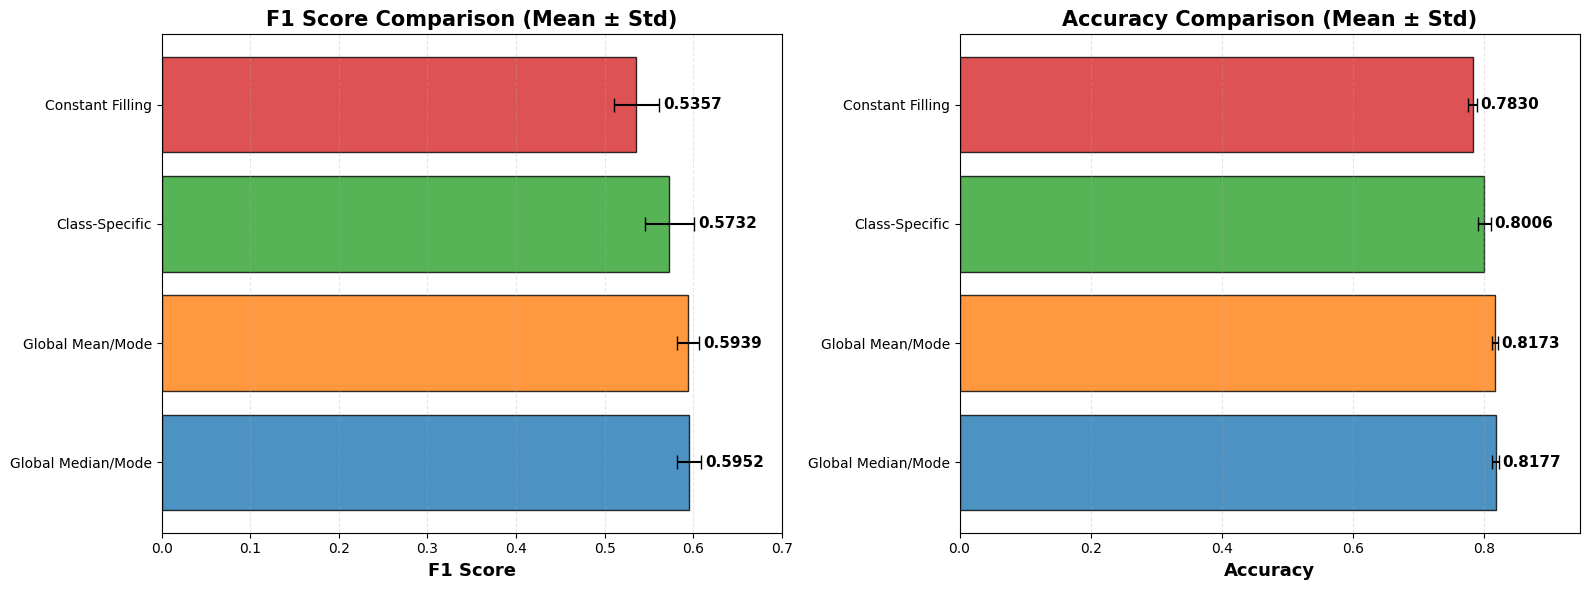

In [8]:
# Visualization: Bar chart comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# F1 Score comparison
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
bars1 = ax1.barh(
    results_df["Method"],
    results_df["F1_Mean"],
    xerr=results_df["F1_Std"],
    capsize=5,
    color=colors,
    alpha=0.8,
    edgecolor="black",
)

# Add value labels
for i, (mean, std) in enumerate(zip(results_df["F1_Mean"], results_df["F1_Std"])):
    ax1.text(
        mean + std + 0.005,
        i,
        f"{mean:.4f}",
        va="center",
        fontsize=11,
        fontweight="bold",
    )

ax1.set_xlabel("F1 Score", fontsize=13, fontweight="bold")
ax1.set_title("F1 Score Comparison (Mean ± Std)", fontsize=15, fontweight="bold")
ax1.grid(axis="x", alpha=0.3, linestyle="--")
ax1.set_xlim(0, max(results_df["F1_Mean"] + results_df["F1_Std"]) * 1.15)

# Accuracy comparison
bars2 = ax2.barh(
    results_df["Method"],
    results_df["Accuracy_Mean"],
    xerr=results_df["Accuracy_Std"],
    capsize=5,
    color=colors,
    alpha=0.8,
    edgecolor="black",
)

# Add value labels
for i, (mean, std) in enumerate(
    zip(results_df["Accuracy_Mean"], results_df["Accuracy_Std"])
):
    ax2.text(
        mean + std + 0.005,
        i,
        f"{mean:.4f}",
        va="center",
        fontsize=11,
        fontweight="bold",
    )

ax2.set_xlabel("Accuracy", fontsize=13, fontweight="bold")
ax2.set_title("Accuracy Comparison (Mean ± Std)", fontsize=15, fontweight="bold")
ax2.grid(axis="x", alpha=0.3, linestyle="--")
ax2.set_xlim(0, max(results_df["Accuracy_Mean"] + results_df["Accuracy_Std"]) * 1.15)

plt.tight_layout()
plt.show()

In [9]:
# Highlight best method
best_method = results_df.iloc[0]["Method"]
best_f1 = results_df.iloc[0]["F1_Mean"]
best_f1_std = results_df.iloc[0]["F1_Std"]
best_acc = results_df.iloc[0]["Accuracy_Mean"]
best_acc_std = results_df.iloc[0]["Accuracy_Std"]

print("\n" + "=" * 80)
print("🏆 BEST IMPUTATION METHOD")
print("=" * 80)
print(f"Method: {best_method}")
print(f"F1 Score: {best_f1:.4f} ± {best_f1_std:.4f}")
print(f"Accuracy: {best_acc:.4f} ± {best_acc_std:.4f}")
print("=" * 80)


🏆 BEST IMPUTATION METHOD
Method: Global Median/Mode
F1 Score: 0.5952 ± 0.0138
Accuracy: 0.8177 ± 0.0054


In [10]:
# Save results to file for future reference
results_df.to_csv("../reports/missing_value_experiments_results.csv", index=False)
print("Results saved to: ../reports/missing_value_experiments_results.csv")

Results saved to: ../reports/missing_value_experiments_results.csv
